## Project1 Titanic dataset EDA
- [Titanic Dataset](https://www.kaggle.com/competitions/titanic)
1. Load Titanic dataset, inspect missingness and dtypes.
2. Analyze survival rates by sex, class, age buckets.
3. Visualize findings (bar charts, violin/boxplots).
4. Write a short insight report (3–5 bullets).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("titanic.csv")
data.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [3]:
print("Shape:", data.shape)
print("Data Types:")
print(data.dtypes)

Shape: (891, 12)
Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [4]:
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
print("Summary Statistics:")
data.describe()

Summary Statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Missing values visualization

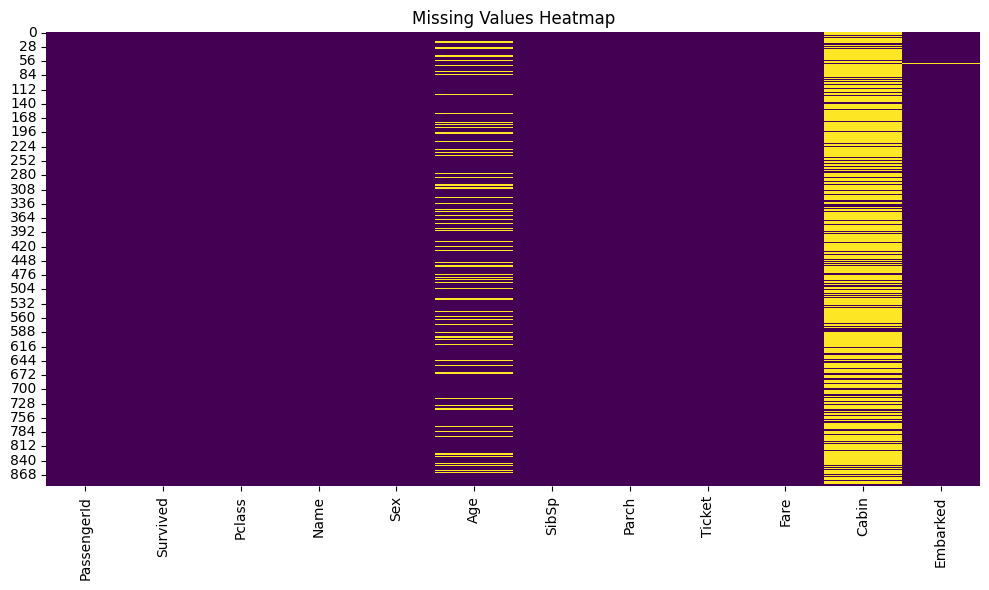

In [6]:
plt.figure(figsize=(10,6))
sns.heatmap(data.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.savefig("missing_values_heatmap.png")
plt.show()

### survival rate by ```Gender```

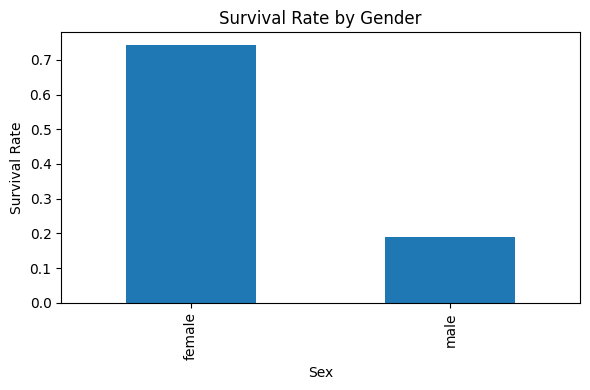

In [7]:
survival_gender = data.groupby("Sex")["Survived"].mean()
plt.figure(figsize=(6,4))
survival_gender.plot(kind="bar")
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.savefig("survival_gender.png")
plt.show()

In [8]:
print("Survival Rate by Gender:")
print(survival_gender)

Survival Rate by Gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


### survival rate by ```Class```

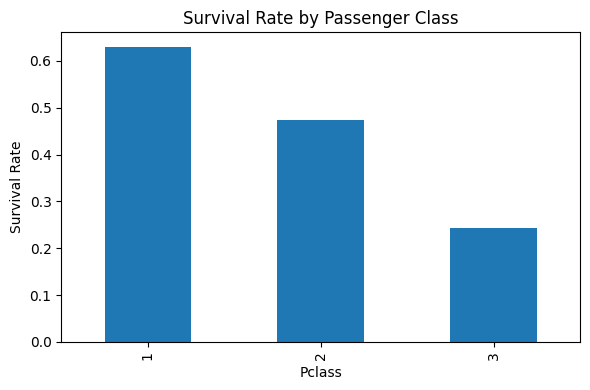

In [9]:
survival_class = data.groupby("Pclass")["Survived"].mean()

plt.figure(figsize=(6,4))
survival_class.plot(kind="bar")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.savefig("survival_class.png")
plt.show()

### Age buckets

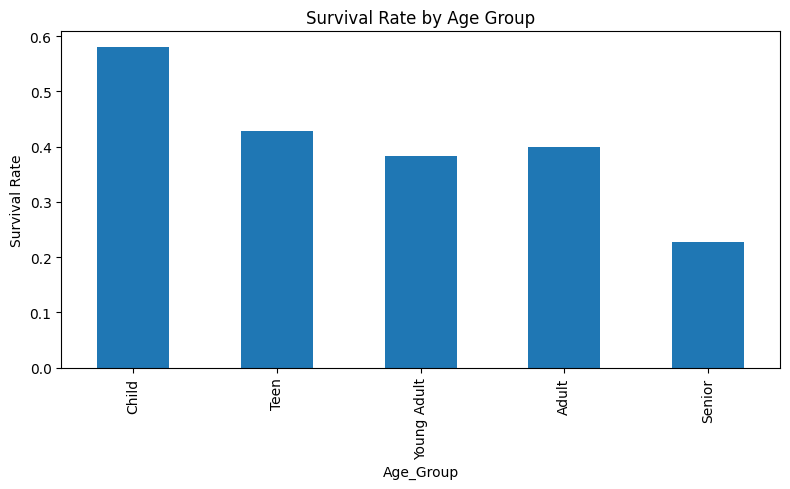

In [10]:
bins = [0,12,18,35,60,100]
labels = ["Child","Teen","Young Adult","Adult","Senior"]

data["Age_Group"] = pd.cut(data["Age"],
                         bins=bins,
                         labels=labels)

survival_age = data.groupby("Age_Group")["Survived"].mean()

plt.figure(figsize=(8,5))
survival_age.plot(kind="bar")
plt.title("Survival Rate by Age Group")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.savefig("survival_age_group.png")
plt.show()


### Boxplot

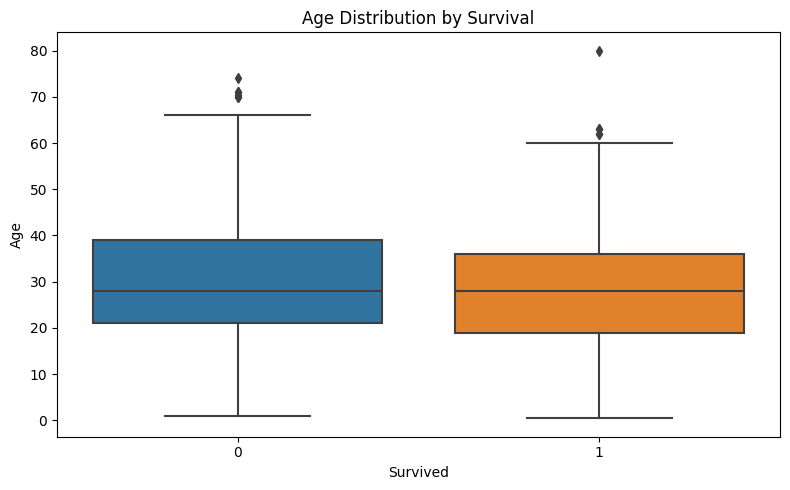

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Survived", y="Age", data=data)
plt.title("Age Distribution by Survival")
plt.tight_layout()
plt.savefig("age_boxplot.png")
plt.show()

### Violin Plot

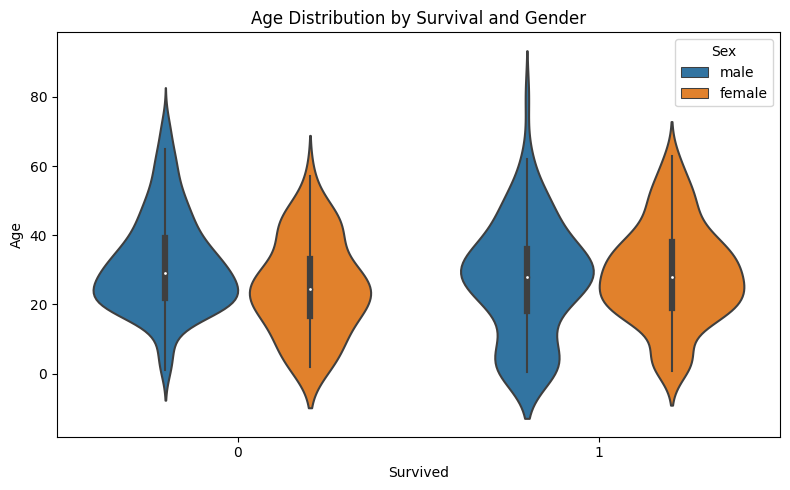

In [12]:
plt.figure(figsize=(8,5))
sns.violinplot(x="Survived", y="Age", hue="Sex",data=data, split=False)
plt.title("Age Distribution by Survival and Gender")
plt.tight_layout()
plt.savefig("age_violinplot.png")
plt.show()

### Insights Report

In [13]:
print("Insights")
print("1. Females had significantly higher survival rates.")
print("2. First-class passengers survived more frequently.")
print("3. Children generally had better survival chances.")
print("4. Older passengers showed lower survival probability.")
print("5. Missing values are concentrated in Age, Cabin, and Embarked.")

Insights
1. Females had significantly higher survival rates.
2. First-class passengers survived more frequently.
3. Children generally had better survival chances.
4. Older passengers showed lower survival probability.
5. Missing values are concentrated in Age, Cabin, and Embarked.
